In [672]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn (1).csv")
df.head()



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [673]:
df.shape

(7043, 21)

In [674]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [675]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [676]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [677]:
df.duplicated().sum()

np.int64(0)

In [678]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Summary Statistics

- Dataset contains 7,043 customers.
- Average customer tenure is approximately 32 months.
- Average monthly charge is $64.76.
- Customer tenure ranges from 0 to 72 months.
- Monthly charges range from $18.25 to $118.75.
- Approximately 16.2% of customers are senior citizens.
- `TotalCharges` is not included in the summary statistics, indicating it may not be stored as a numeric column.

In [679]:
df.describe(include='object')

C:\Users\tusha\AppData\Local\Temp\ipykernel_28232\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [680]:
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [681]:
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: str

In [682]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [683]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [684]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [685]:
df["TotalCharges"].dtype

dtype('float64')

In [686]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [687]:
df = df.dropna()

In [688]:
df.shape


(7032, 21)

In [689]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [690]:
df.shape

(7032, 21)

In [691]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print(churn_rate)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


## Overall Churn Rate

Approximately 26.57% of customers have churned while 73.42% remain with the company.

Reducing churn even by a small percentage could significantly improve customer retention and recurring revenue.

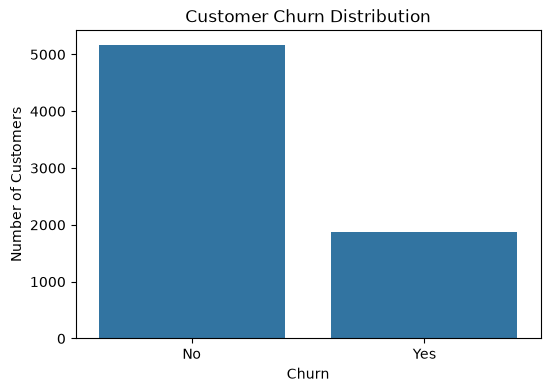

In [692]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [693]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [694]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


## Analysis 1: Contract Type

### Business Question
Does the type of contract affect customer churn?

### Observation
- 42.71% of customers with month-to-month contracts churn.
- Only 11.28% of one-year contract customers churn.
- Only 2.85% of two-year contract customers churn.

### Business Insight
Contract type is one of the strongest predictors of customer churn. Customers with month-to-month contracts are significantly more likely to leave than customers with long-term contracts.

### Recommendation
Encourage month-to-month customers to switch to annual or two-year contracts by offering loyalty discounts, promotional pricing, or additional benefits.

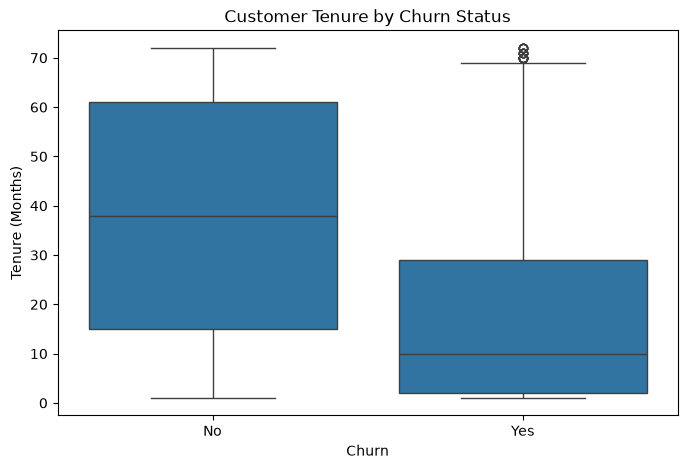

In [695]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [696]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


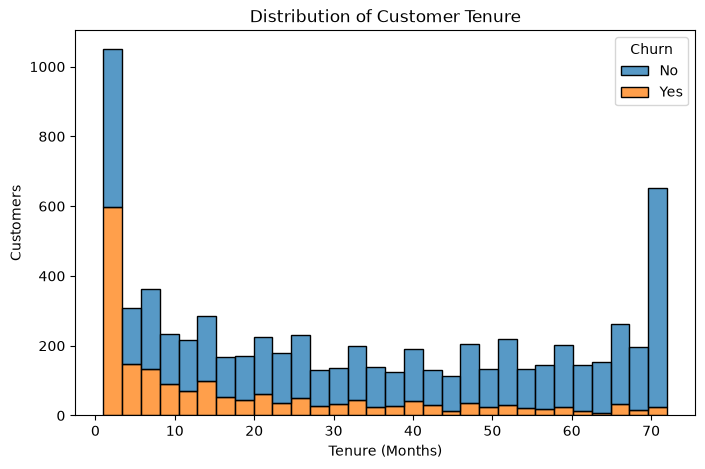

In [697]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    multiple="stack"
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Customers")

plt.show()

## Analysis 2: Customer Tenure vs Churn

### Business Question
Does customer tenure influence customer churn?

### Observation
- Customers with low tenure (especially within the first 10 months) show the highest churn.
- As customer tenure increases, the number of churned customers decreases significantly.
- Customers who have remained with the company for more than 60 months rarely churn.

### Business Insight
Customer churn is highest during the early stages of the customer lifecycle. Customers who stay with the company for a longer period tend to become more loyal and are much less likely to leave.

### Recommendation
The company should strengthen its onboarding and customer engagement programs during the first year. Early retention campaigns, personalized support, and loyalty incentives can help reduce churn among new customers.

In [698]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


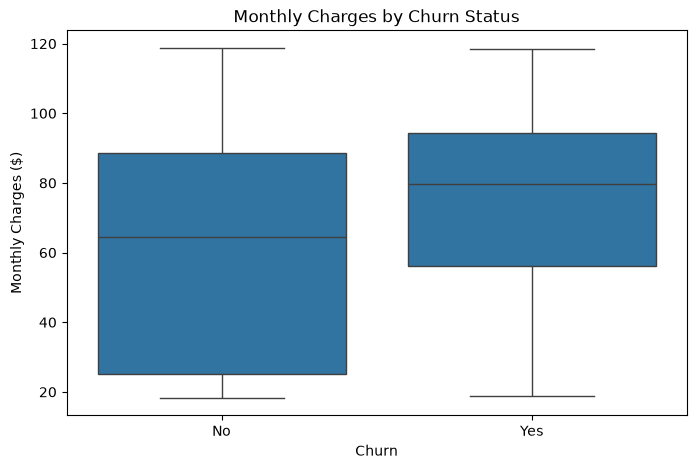

In [699]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges ($)")

plt.show()

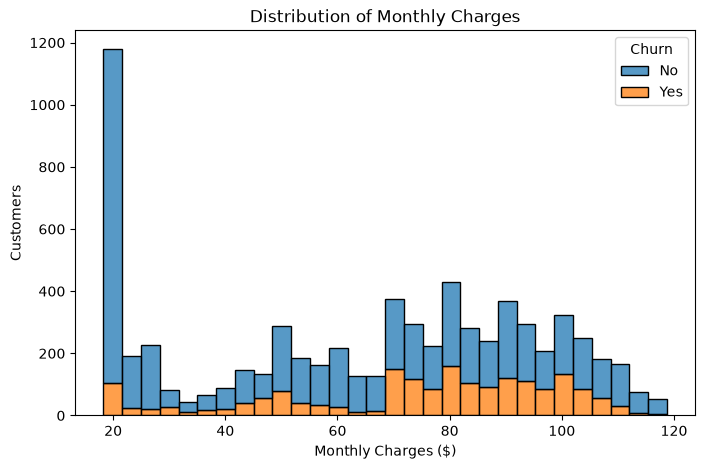

In [700]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    bins=30,
    multiple="stack"
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Customers")

plt.show()

## Analysis 3: Monthly Charges vs Churn

### Business Question
Do higher monthly charges increase customer churn?

### Observation
- Customers who churn have a higher average monthly charge ($74.44) compared to customers who stay ($61.31).
- The median monthly charge is also higher for churned customers.
- The boxplot shows that churned customers are concentrated in the higher monthly charge range.
- The histogram also indicates that customers paying higher monthly charges experience more churn than customers with lower monthly charges.

### Business Insight
Monthly charges appear to be an important factor influencing customer churn. Customers paying higher monthly fees are more likely to leave the company, suggesting that pricing or perceived value may be affecting customer retention.

### Recommendation
The company should focus on retaining customers with high monthly charges by offering personalized discounts, loyalty rewards, bundled service packages, or premium customer support to increase the perceived value of their subscription.

In [701]:
df.groupby("Churn")["TotalCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,2555.344141,2329.456984,18.80,577.825,1683.60,4264.125,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.500,703.55,2331.300,8684.80


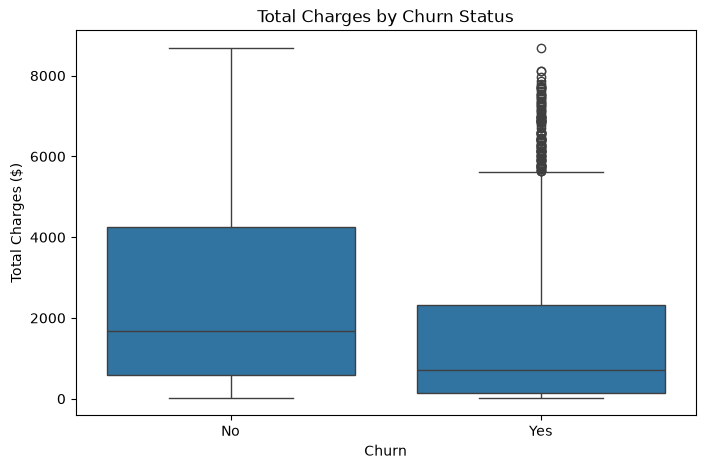

In [702]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges ($)")

plt.show()

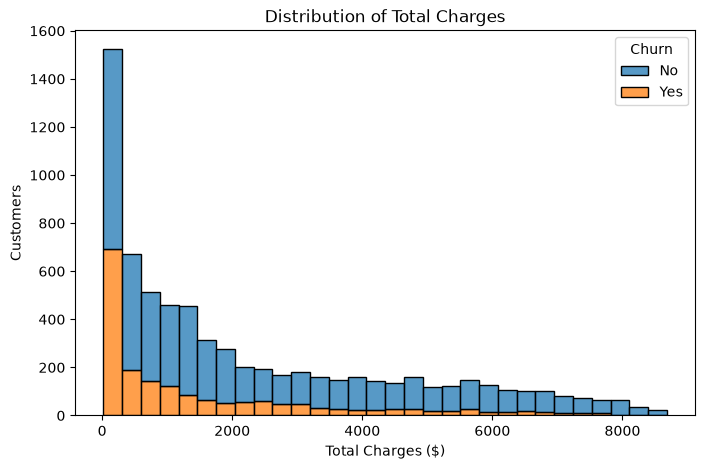

In [703]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="TotalCharges",
    hue="Churn",
    bins=30,
    multiple="stack"
)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges ($)")
plt.ylabel("Customers")

plt.show()

## Analysis 4: Total Charges vs Churn

### Business Question
Does the total amount spent by a customer influence customer churn?

### Statistical Evidence
- Average Total Charges (Stayed): **$2555.34**
- Average Total Charges (Churned): **$1531.80**
- Median Total Charges (Stayed): **$1683.60**
- Median Total Charges (Churned): **$703.55**

### Observation
- Customers who stayed with the company have significantly higher total charges than customers who churned.
- The median total charges of retained customers are more than twice those of churned customers.
- A few customers with high total charges still churn, but they represent a small portion of the dataset.

### Business Insight
Customers with higher lifetime spending are generally more loyal to the company. Lower total charges among churned customers indicate that many customers leave before building a long-term relationship with the company.

### Recommendation
The company should prioritize retaining customers during their first year of service through onboarding programs, loyalty incentives, and proactive customer engagement. Increasing early retention will naturally improve customer lifetime value.

### Business Impact
Reducing early churn can increase customer lifetime value (CLV), improve recurring revenue, and lower the cost of acquiring replacement customers.

### Connection with Previous Findings
This analysis supports previous findings:
- Month-to-month customers have the highest churn.
- Customers with shorter tenure are more likely to churn.
- Shorter tenure leads to lower accumulated Total Charges.

In [704]:
pd.crosstab(df["InternetService"], df["Churn"])

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


In [705]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


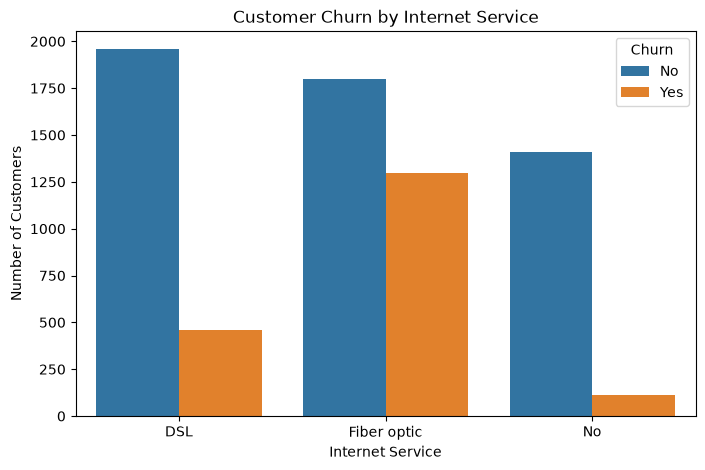

In [706]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

## Analysis 5: Internet Service vs Churn

### Business Question
Does the type of internet service affect customer churn?

### Statistical Evidence
- DSL Churn Rate: **18.99%**
- Fiber Optic Churn Rate: **41.89%**
- No Internet Service Churn Rate: **7.43%**

### Observation
- Fiber optic customers have the highest churn rate.
- DSL customers experience a much lower churn rate.
- Customers without internet service have the lowest churn rate.

### Business Insight
Fiber optic customers are significantly more likely to churn than customers using DSL or no internet service. This may indicate issues related to pricing, service quality, or customer expectations. Further investigation is required to identify the exact cause.

### Recommendation
The company should focus on improving the retention of Fiber optic customers through service quality improvements, competitive pricing, loyalty rewards, and customer feedback programs.

### Business Impact
Reducing churn among Fiber optic customers can have a significant positive impact on long-term revenue because these customers are likely to generate higher monthly revenue.

### Connection with Previous Findings
This analysis supports our previous findings that customers with higher monthly charges tend to churn more frequently. Since Fiber optic plans are typically associated with higher monthly charges, the higher churn rate among Fiber optic customers may be linked to pricing or perceived value.

In [707]:
pd.crosstab(df["OnlineSecurity"], df["Churn"])

Churn,No,Yes
OnlineSecurity,,
No,2036,1461
No internet service,1407,113
Yes,1720,295


In [708]:
pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


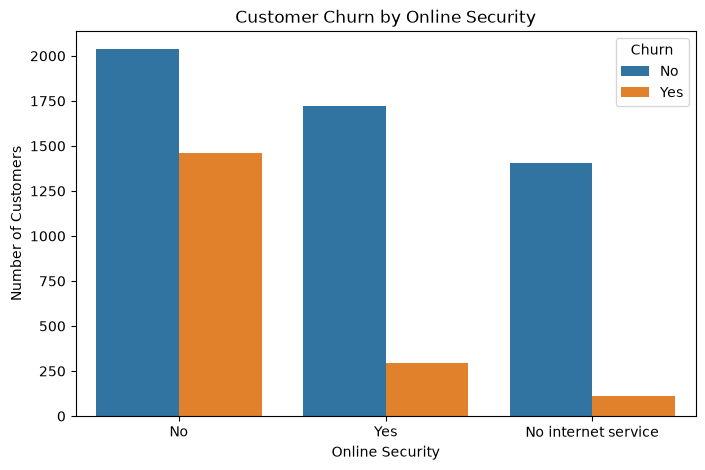

In [709]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="OnlineSecurity",
    hue="Churn"
)

plt.title("Customer Churn by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")

plt.show()

## Analysis 6: Online Security vs Churn

### Business Question
Does subscribing to Online Security reduce customer churn?

### Statistical Evidence
- Customers without Online Security: **41.78% churn**
- Customers with Online Security: **14.64% churn**
- Customers without Internet Service: **7.43% churn**

### Observation
- Customers without Online Security have the highest churn rate.
- Customers who subscribe to Online Security are significantly less likely to churn.
- Customers without Internet Service have the lowest churn rate.

### Business Insight
Online Security appears to be strongly associated with customer retention. Customers who subscribe to Online Security are much more likely to remain with the company. This suggests that value-added services increase customer loyalty and perceived value.

### Recommendation
The company should encourage customers to subscribe to Online Security through promotional offers, discounted bundles, or free trial periods. Increasing adoption of Online Security may help reduce customer churn.

### Business Impact
Increasing Online Security adoption can improve customer retention, increase customer lifetime value, and generate additional recurring revenue.

### Connection with Previous Findings
This analysis supports previous findings that customers receiving greater value from company services tend to remain longer. Customers using Online Security are less likely to churn despite paying for an additional service.

In [710]:
pd.crosstab(df["TechSupport"], df["Churn"])

Churn,No,Yes
TechSupport,,
No,2026,1446
No internet service,1407,113
Yes,1730,310


In [711]:
pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


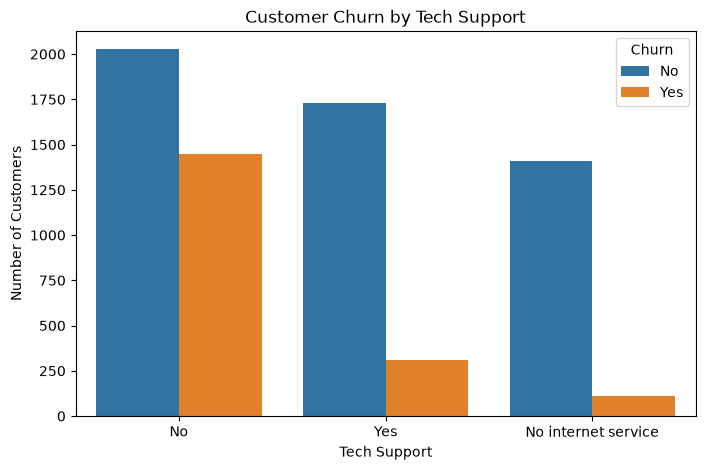

In [712]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn"
)

plt.title("Customer Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

plt.show()

## Analysis 7: Tech Support vs Churn

### Business Question
Does having Tech Support reduce customer churn?

### Statistical Evidence
- Customers without Tech Support: **41.65% churn**
- Customers with Tech Support: **15.20% churn**
- Customers without Internet Service: **7.43% churn**

### Observation
- Customers without Tech Support have the highest churn rate (41.65%).
- Customers who subscribe to Tech Support have a much lower churn rate (15.20%).
- Customers without Internet Service have the lowest churn rate (7.43%).

### Business Insight
Customers who receive Tech Support are significantly more likely to remain with the company. This suggests that providing timely assistance and resolving customer issues improves customer satisfaction and reduces the likelihood of churn.

### Recommendation
The company should increase adoption of Tech Support by offering free trials, bundled packages, or promotional discounts. Improving the quality and accessibility of technical support can further enhance customer retention.

### Business Impact
Increasing Tech Support adoption can improve customer satisfaction, reduce churn, and increase customer lifetime value.

### Connection with Previous Findings
This finding supports the Online Security analysis. Customers who subscribe to value-added services such as Online Security and Tech Support are considerably less likely to churn, indicating that customers who engage with more company services tend to be more loyal.

In [713]:
pd.crosstab(df["OnlineBackup"], df["Churn"])

Churn,No,Yes
OnlineBackup,,
No,1854,1233
No internet service,1407,113
Yes,1902,523


In [714]:
pd.crosstab(
    df["OnlineBackup"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
OnlineBackup,,
No,60.058309,39.941691
No internet service,92.565789,7.434211
Yes,78.432990,21.567010


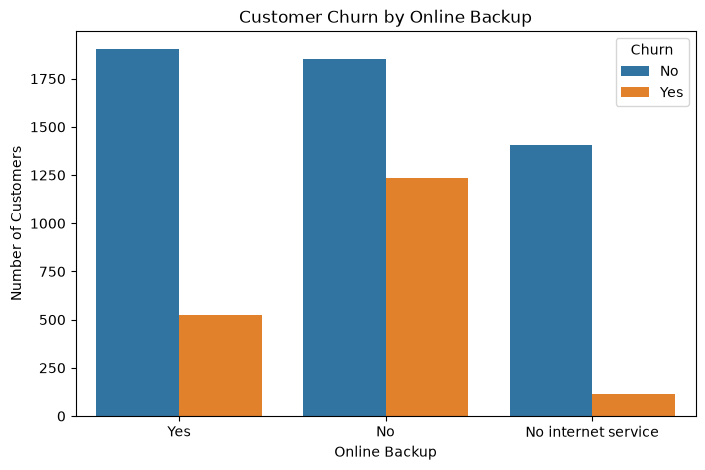

In [715]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="OnlineBackup",
    hue="Churn"
)

plt.title("Customer Churn by Online Backup")
plt.xlabel("Online Backup")
plt.ylabel("Number of Customers")

plt.show()

## Analysis 8: Online Backup vs Churn

### Business Question
Does subscribing to Online Backup reduce customer churn?

### Statistical Evidence
- Customers without Online Backup: **39.94% churn**
- Customers with Online Backup: **21.57% churn**
- Customers without Internet Service: **7.43% churn**

### Observation
- Customers without Online Backup have a significantly higher churn rate than customers who subscribe to the service.
- Customers using Online Backup are considerably more likely to remain with the company.
- Customers without Internet Service have the lowest churn rate.

### Business Insight
Online Backup appears to contribute to customer retention. Customers who subscribe to Online Backup are less likely to leave, suggesting that value-added services increase customer engagement and make switching providers less attractive.

### Recommendation
The company should promote Online Backup through bundled packages, free trial offers, or discounted pricing to encourage adoption and improve customer retention.

### Business Impact
Increasing Online Backup adoption can improve customer loyalty, increase customer lifetime value (CLV), and reduce revenue loss caused by customer churn.

### Connection with Previous Findings
This analysis reinforces previous findings that customers using additional services such as Online Security, Tech Support, and Online Backup are significantly less likely to churn than customers who only subscribe to basic services.

In [716]:
pd.crosstab(df["DeviceProtection"], df["Churn"])

Churn,No,Yes
DeviceProtection,,
No,1883,1211
No internet service,1407,113
Yes,1873,545


In [717]:
pd.crosstab(
    df["DeviceProtection"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
DeviceProtection,,
No,60.859729,39.140271
No internet service,92.565789,7.434211
Yes,77.460711,22.539289


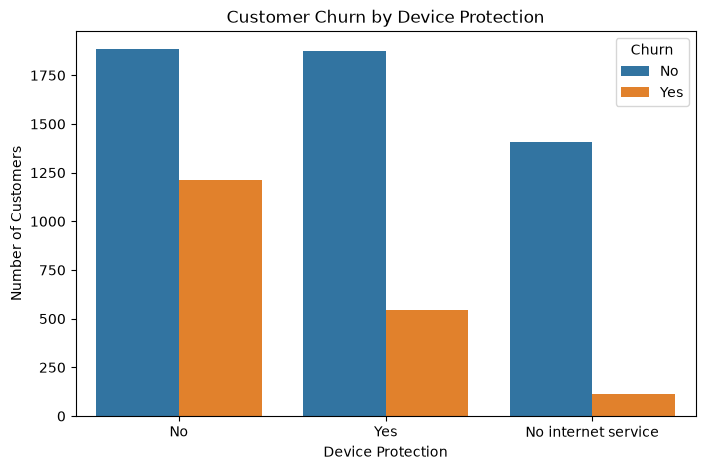

In [718]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="DeviceProtection",
    hue="Churn"
)

plt.title("Customer Churn by Device Protection")
plt.xlabel("Device Protection")
plt.ylabel("Number of Customers")

plt.show()

## Analysis 9: Device Protection vs Churn

### Business Question
Does subscribing to Device Protection reduce customer churn?

### Statistical Evidence
- Customers without Device Protection: **39.14% churn**
- Customers with Device Protection: **22.54% churn**
- Customers without Internet Service: **7.43% churn**

### Observation
- Customers without Device Protection have a significantly higher churn rate (39.14%) than customers who subscribe to the service (22.54%).
- Customers with Device Protection are considerably more likely to stay with the company.
- Customers without Internet Service have the lowest churn rate.

### Business Insight
Device Protection is associated with improved customer retention. Customers who subscribe to Device Protection appear more engaged with the company's services and are less likely to switch to competitors.

### Recommendation
The company should increase adoption of Device Protection through bundled plans, promotional discounts, and free trial offers to improve customer retention.

### Business Impact
Increasing Device Protection adoption can improve customer loyalty, reduce churn, and increase customer lifetime value (CLV).

### Connection with Previous Findings
This finding further supports the pattern observed with Online Security, Tech Support, and Online Backup. Customers who subscribe to additional value-added services consistently show lower churn rates than customers who only use basic services.

In [719]:
pd.crosstab(df["StreamingTV"], df["Churn"])

Churn,No,Yes
StreamingTV,,
No,1867,942
No internet service,1407,113
Yes,1889,814


In [720]:
pd.crosstab(
    df["StreamingTV"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
StreamingTV,,
No,66.464934,33.535066
No internet service,92.565789,7.434211
Yes,69.885313,30.114687


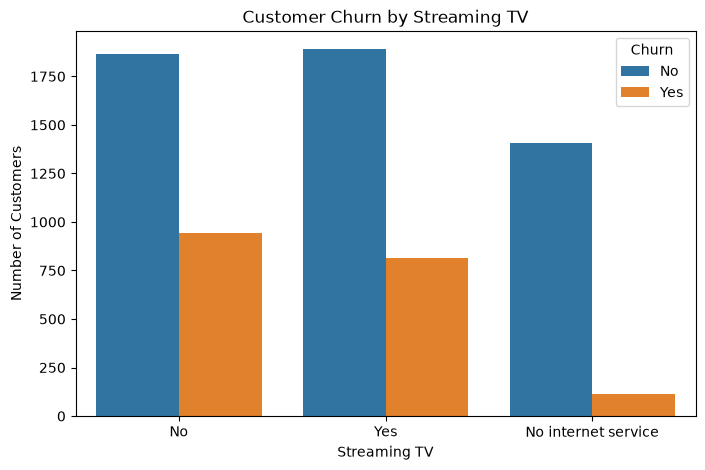

In [721]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="StreamingTV",
    hue="Churn"
)

plt.title("Customer Churn by Streaming TV")
plt.xlabel("Streaming TV")
plt.ylabel("Number of Customers")

plt.show()

## Analysis 10: Streaming TV vs Churn

### Business Question
Does subscribing to Streaming TV influence customer churn?

### Statistical Evidence
- Customers without Streaming TV: **33.54% churn**
- Customers with Streaming TV: **30.11% churn**
- Customers without Internet Service: **7.43% churn**

### Observation
- Customers without Streaming TV have a churn rate of 33.54%.
- Customers with Streaming TV have a slightly lower churn rate of 30.11%.
- The difference in churn between customers with and without Streaming TV is relatively small.

### Business Insight
Unlike Online Security, Tech Support, and Device Protection, Streaming TV does not appear to have a strong influence on customer retention. Entertainment services alone are unlikely to be a major factor affecting customer churn.

### Recommendation
The company should not rely on Streaming TV as a primary customer retention strategy. Instead, retention efforts should focus on services that demonstrate a much stronger relationship with churn, such as Online Security and Tech Support.

### Business Impact
Investing in customer support and value-added security services is likely to produce a greater reduction in churn than promoting entertainment services alone.

### Connection with Previous Findings
This analysis suggests that not all additional services contribute equally to customer retention. Functional services such as Online Security and Tech Support have a much stronger impact on reducing churn than entertainment services like Streaming TV.

In [722]:
pd.crosstab(df["StreamingMovies"], df["Churn"])

Churn,No,Yes
StreamingMovies,,
No,1843,938
No internet service,1407,113
Yes,1913,818


In [723]:
pd.crosstab(
    df["StreamingMovies"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
StreamingMovies,,
No,66.271125,33.728875
No internet service,92.565789,7.434211
Yes,70.047602,29.952398


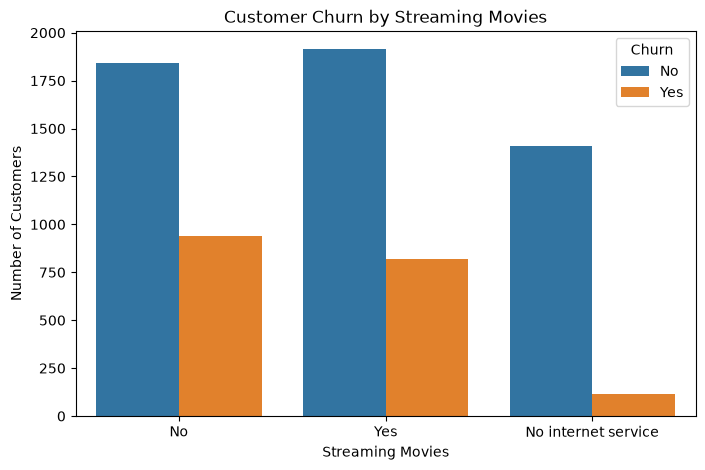

In [724]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="StreamingMovies",
    hue="Churn"
)

plt.title("Customer Churn by Streaming Movies")
plt.xlabel("Streaming Movies")
plt.ylabel("Number of Customers")

plt.show()

## Analysis 11: Streaming Movies vs Churn

### Business Question
Does subscribing to Streaming Movies influence customer churn?

### Statistical Evidence
- Customers without Streaming Movies: **33.73% churn**
- Customers with Streaming Movies: **29.95% churn**
- Customers without Internet Service: **7.43% churn**

### Observation
- Customers without Streaming Movies have a churn rate of 33.73%.
- Customers with Streaming Movies have a slightly lower churn rate of 29.95%.
- The difference between the two groups is relatively small.

### Business Insight
Streaming Movies does not appear to be a major factor influencing customer churn. Unlike functional services such as Online Security and Tech Support, entertainment services have only a limited relationship with customer retention.

### Recommendation
The company should prioritize improving functional services rather than relying on entertainment services as a customer retention strategy.

### Business Impact
Investments in customer support and security services are likely to provide a greater return in reducing churn than expanding entertainment features.

### Connection with Previous Findings
This analysis confirms the findings from Streaming TV. Entertainment services have a relatively weak impact on customer retention, whereas functional services such as Online Security, Tech Support, Online Backup, and Device Protection show a much stronger relationship with reduced churn.

In [725]:
pd.crosstab(df["PaymentMethod"], df["Churn"])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


In [726]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


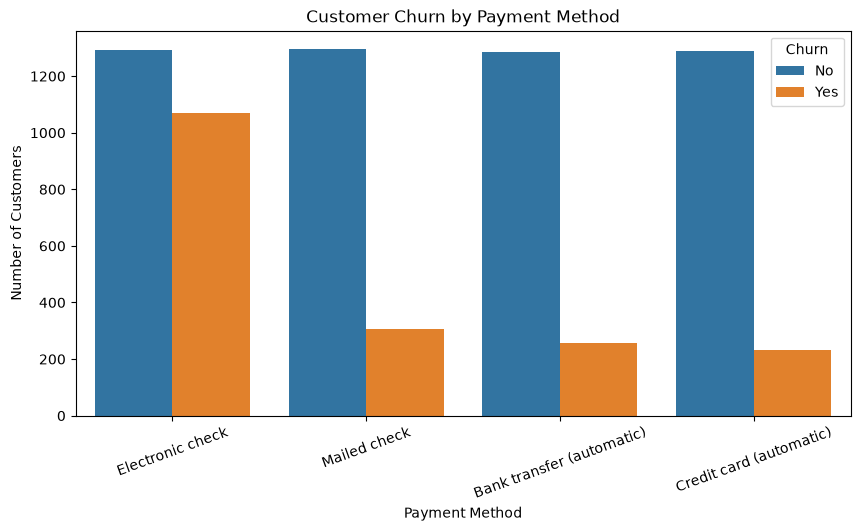

In [727]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Customer Churn by Payment Method")
plt.xticks(rotation=20)
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.show()

## Analysis 12: Payment Method vs Churn

### Business Question
Does the customer's payment method influence customer churn?

### Statistical Evidence
- Electronic Check: **45.29% churn**
- Mailed Check: **19.20% churn**
- Bank Transfer (Automatic): **16.73% churn**
- Credit Card (Automatic): **15.25% churn**

### Observation
- Customers using Electronic Check have the highest churn rate (45.29%).
- Customers using automatic payment methods have the lowest churn rates.
- Credit Card (Automatic) customers have the lowest churn rate among all payment methods.

### Business Insight
Payment method is a strong indicator of customer churn. Customers enrolled in automatic payment methods are significantly more likely to remain with the company, while customers using Electronic Check are much more likely to leave.

### Recommendation
The company should encourage Electronic Check customers to switch to automatic payment methods by offering incentives such as cashback, discounts, or loyalty rewards.

### Business Impact
Increasing the adoption of automatic payment methods can improve customer retention, create more predictable recurring revenue, and reduce customer churn.

### Connection with Previous Findings
This finding complements previous analyses by showing that customer commitment and engagement play an important role in retention. Similar to long-term contracts and value-added services, automatic payment methods are associated with lower churn rates.

In [728]:
pd.crosstab(df["PaperlessBilling"], df["Churn"])

Churn,No,Yes
PaperlessBilling,,
No,2395,469
Yes,2768,1400


In [729]:
pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaperlessBilling,,
No,83.624302,16.375698
Yes,66.410749,33.589251


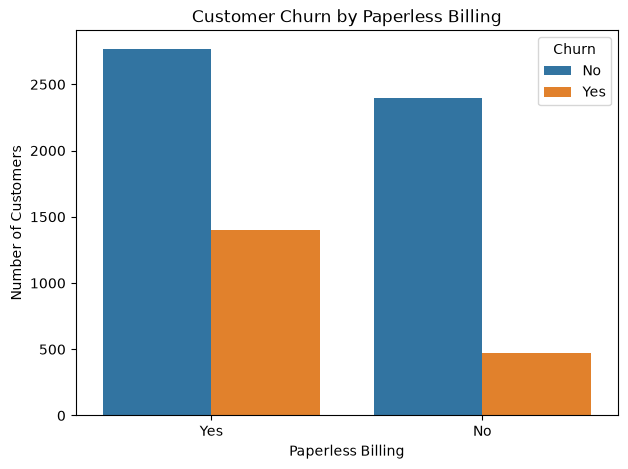

In [730]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="PaperlessBilling",
    hue="Churn"
)

plt.title("Customer Churn by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Number of Customers")

plt.show()

## Analysis 13: Paperless Billing vs Churn

### Business Question
Does Paperless Billing influence customer churn?

### Statistical Evidence
- Customers with Paperless Billing: **33.59% churn**
- Customers without Paperless Billing: **16.38% churn**

### Observation
- Customers using Paperless Billing have more than twice the churn rate of customers who do not use Paperless Billing.
- The count plot also shows a noticeably larger proportion of churned customers among Paperless Billing users.

### Business Insight
Paperless Billing is associated with higher customer churn. However, this relationship may be influenced by other factors such as contract type or payment method rather than Paperless Billing itself.

### Recommendation
The company should investigate why customers using Paperless Billing churn more frequently. Special attention should be given to customers who also use Electronic Check or Month-to-Month contracts.

### Business Impact
Identifying high-risk Paperless Billing customers can help the company launch targeted retention campaigns and reduce churn.

### Connection with Previous Findings
This finding complements previous analyses showing that customers with Month-to-Month contracts and Electronic Check payments are at the highest risk of churn. These customer segments may overlap and should be investigated further.

In [731]:
def analyze_categorical(column):
    print(f"\n===== {column} =====\n")

    print(pd.crosstab(df[column], df["Churn"]))

    print("\nPercentage Table\n")

    print(pd.crosstab(
        df[column],
        df["Churn"],
        normalize="index"
    ) * 100)

    plt.figure(figsize=(7,5))

    sns.countplot(
        data=df,
        x=column,
        hue="Churn"
    )

    plt.title(f"Customer Churn by {column}")

    plt.show()


===== SeniorCitizen =====

Churn            No   Yes
SeniorCitizen            
0              4497  1393
1               666   476

Percentage Table

Churn                 No        Yes
SeniorCitizen                      
0              76.349745  23.650255
1              58.318739  41.681261


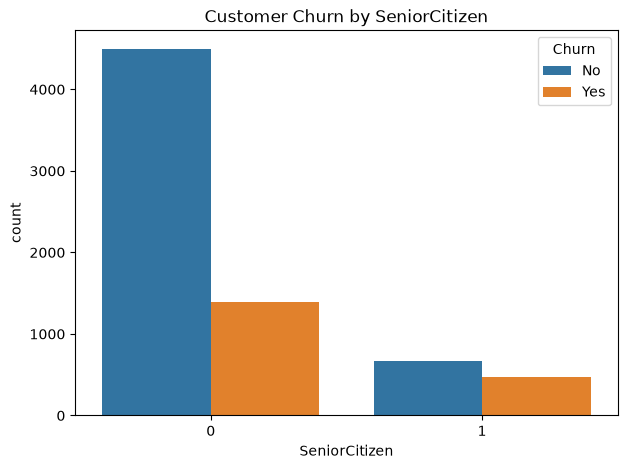


===== Partner =====

Churn      No   Yes
Partner            
No       2439  1200
Yes      2724   669

Percentage Table

Churn           No        Yes
Partner                      
No       67.023908  32.976092
Yes      80.282935  19.717065


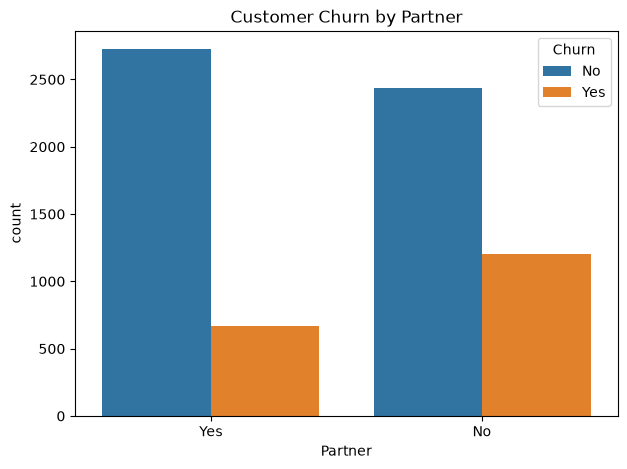


===== Dependents =====

Churn         No   Yes
Dependents            
No          3390  1543
Yes         1773   326

Percentage Table

Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.468795  15.531205


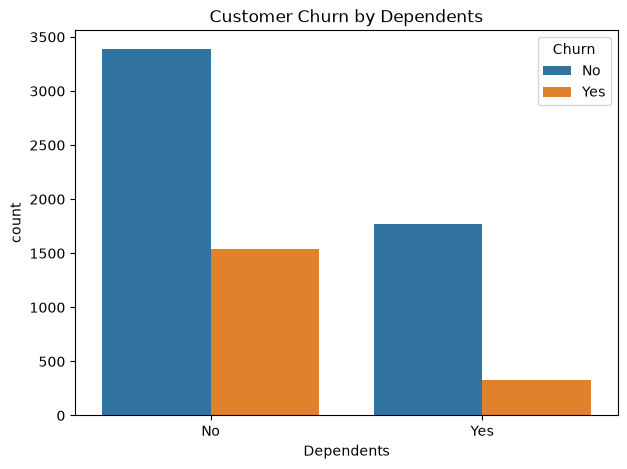


===== gender =====

Churn     No  Yes
gender           
Female  2544  939
Male    2619  930

Percentage Table

Churn          No        Yes
gender                      
Female  73.040482  26.959518
Male    73.795435  26.204565


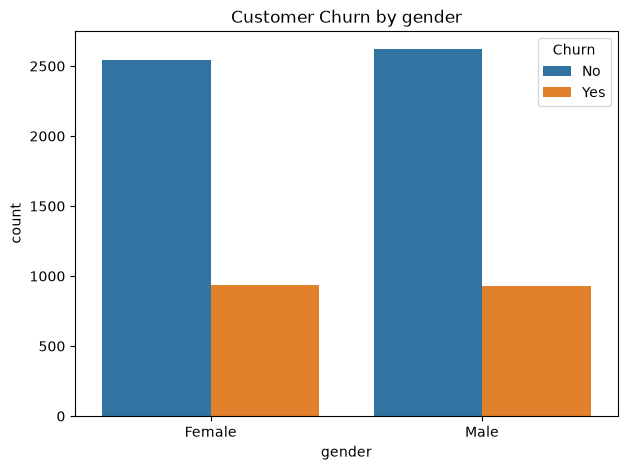

In [732]:
analyze_categorical("SeniorCitizen")
analyze_categorical("Partner")
analyze_categorical("Dependents")
analyze_categorical("gender")

## Analysis 14: Senior Citizen vs Churn

### Business Question
Are senior citizens more likely to churn than non-senior customers?

### Statistical Evidence
- Non-Senior Citizens: **23.65% churn**
- Senior Citizens: **41.68% churn**

### Observation
Senior citizens have a significantly higher churn rate than non-senior customers.

### Business Insight
Senior citizens appear to be a high-risk customer segment and may require more personalized support and retention efforts.

### Recommendation
Provide senior customers with dedicated customer support, loyalty programs, and simplified service plans to improve retention.

### Business Impact
Targeted retention strategies for senior citizens can reduce churn within this vulnerable customer segment.

## Analysis 15: Partner vs Churn

### Business Question
Does having a partner influence customer churn?

### Statistical Evidence
- Customers without a partner: **32.98% churn**
- Customers with a partner: **19.72% churn**

### Observation
Customers without a partner are considerably more likely to churn than customers who have a partner.

### Business Insight
Customers with partners may have greater household stability and longer-term service commitments, contributing to lower churn.

### Recommendation
Customers without partners should be considered a higher-risk segment for retention campaigns.

### Business Impact
Segment-specific retention campaigns can help reduce churn among individual customers.

## Analysis 16: Dependents vs Churn

### Business Question
Does having dependents influence customer churn?

### Statistical Evidence
- Customers without dependents: **31.28% churn**
- Customers with dependents: **15.53% churn**

### Observation
Customers without dependents are approximately twice as likely to churn as customers with dependents.

### Business Insight
Customers with dependents are generally more stable and tend to remain with the company for longer periods.

### Recommendation
Customers without dependents should be prioritized in churn prevention campaigns.

### Business Impact
Improving retention among customers without dependents can reduce overall customer churn.

## Analysis 17: Gender vs Churn

### Business Question
Does gender influence customer churn?

### Statistical Evidence
- Female Customers: **26.96% churn**
- Male Customers: **26.20% churn**

### Observation
The churn rates for male and female customers are almost identical.

### Business Insight
Gender has little to no influence on customer churn.

### Recommendation
Gender should not be considered a primary factor when designing customer retention strategies.

### Business Impact
Marketing and retention efforts should focus on behavioral and service-related factors rather than gender.


# Executive Summary

## Objective

The objective of this project was to identify the major factors influencing customer churn and provide actionable business recommendations to improve customer retention.

## Major Findings

The analysis identified several strong indicators of customer churn:

- Customers with Month-to-Month contracts had the highest churn rate (42.71%).
- Customers paying through Electronic Check showed the highest churn rate (45.29%).
- Fiber Optic customers churned significantly more than DSL customers.
- Customers without Online Security or Tech Support were nearly three times more likely to churn.
- Customers without Online Backup or Device Protection also exhibited substantially higher churn rates.
- Customers with shorter tenure and higher monthly charges were more likely to leave the company.
- Senior Citizens showed higher churn than non-senior customers.
- Customers without partners or dependents were more likely to churn.
- Gender had virtually no impact on customer churn.
- Entertainment services such as Streaming TV and Streaming Movies had only a weak relationship with churn.

## Overall Conclusion

Customer churn is primarily driven by customer engagement, contract commitment, payment behavior, and adoption of value-added services rather than demographic characteristics.

Customers using Month-to-Month contracts, Electronic Check payments, and lacking additional services represent the highest-risk customer segment and should be the primary focus of retention strategies.

# Feature Engineering

## Feature 1: Customer Tenure Group

### Objective
Customers at different stages of their relationship with the company may exhibit different churn behaviors.

Instead of using the exact tenure (in months), we group customers into meaningful business categories. This makes it easier to analyze customer lifecycle stages and can improve model interpretability.

### Categories
- New Customer (0–12 months)
- Growing Customer (13–24 months)
- Established Customer (25–48 months)
- Loyal Customer (49–72 months)

In [733]:
# Create tenure groups

bins = [0, 12, 24, 48, 72]
labels = ["New", "Growing", "Established", "Loyal"]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [734]:
df[["tenure", "TenureGroup"]].head(15)

,tenure,TenureGroup
0,1,New
1,34,Established
2,2,New
3,45,Established
4,2,New
5,8,New
6,22,Growing
7,10,New
8,28,Established
9,62,Loyal


In [735]:
df["TenureGroup"].value_counts()

TenureGroup
Loyal          2239
New            2175
Established    1594
Growing        1024
Name: count, dtype: int64

In [736]:
pd.crosstab(df["TenureGroup"], df["Churn"])

Churn,No,Yes
TenureGroup,,
New,1138,1037
Growing,730,294
Established,1269,325
Loyal,2026,213


In [737]:
pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
TenureGroup,,
New,52.321839,47.678161
Growing,71.289062,28.710938
Established,79.611041,20.388959
Loyal,90.486824,9.513176


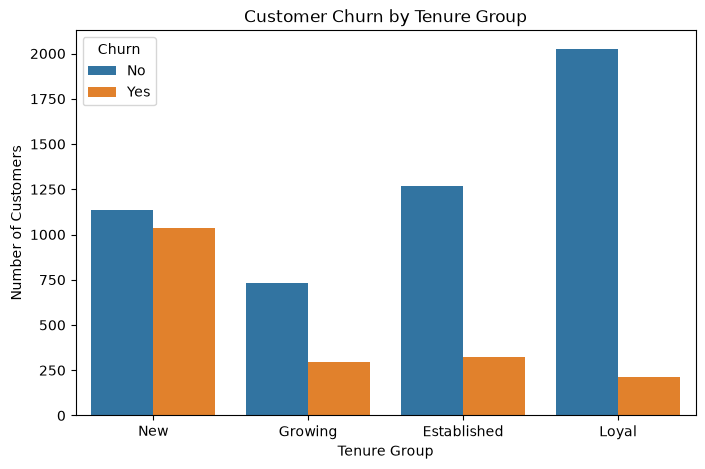

In [738]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="TenureGroup",
    hue="Churn",
    order=["New","Growing","Established","Loyal"]
)

plt.title("Customer Churn by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Customers")

plt.show()

### Business Interpretation

Grouping customers by tenure provides a clearer understanding of customer behavior across different lifecycle stages.

This engineered feature simplifies the analysis by categorizing customers into meaningful business segments instead of relying on raw tenure values. It also helps identify which customer groups require the most attention in customer retention strategies.

## Feature 2: Monthly Charge Category

### Objective

Customers paying different monthly charges may have different churn behaviors.

Instead of analyzing exact monthly charges, we group customers into pricing categories. This simplifies business analysis and allows us to identify which pricing segment has the highest churn.

### Categories

- Low
- Medium
- High
- Premium

In [739]:
df["MonthlyChargeCategory"] = pd.qcut(
    df["MonthlyCharges"],
    q=4,
    labels=["Low", "Medium", "High", "Premium"]
)

In [740]:
df[["MonthlyCharges", "MonthlyChargeCategory"]].head(15)

,MonthlyCharges,MonthlyChargeCategory
0,29.85,Low
1,56.95,Medium
2,53.85,Medium
3,42.30,Medium
4,70.70,High
5,99.65,Premium
6,89.10,High
7,29.75,Low
8,104.80,Premium
9,56.15,Medium


In [741]:
df["MonthlyChargeCategory"].value_counts()

MonthlyChargeCategory
Medium     1761
Low        1758
Premium    1758
High       1755
Name: count, dtype: int64

In [742]:
pd.crosstab(
    df["MonthlyChargeCategory"],
    df["Churn"]
)

Churn,No,Yes
MonthlyChargeCategory,,
Low,1559,199
Medium,1328,433
High,1096,659
Premium,1180,578


In [743]:
pd.crosstab(
    df["MonthlyChargeCategory"],
    df["Churn"],
    normalize="index"
) * 100



Churn,No,Yes
MonthlyChargeCategory,,
Low,88.680319,11.319681
Medium,75.411698,24.588302
High,62.450142,37.549858
Premium,67.121729,32.878271


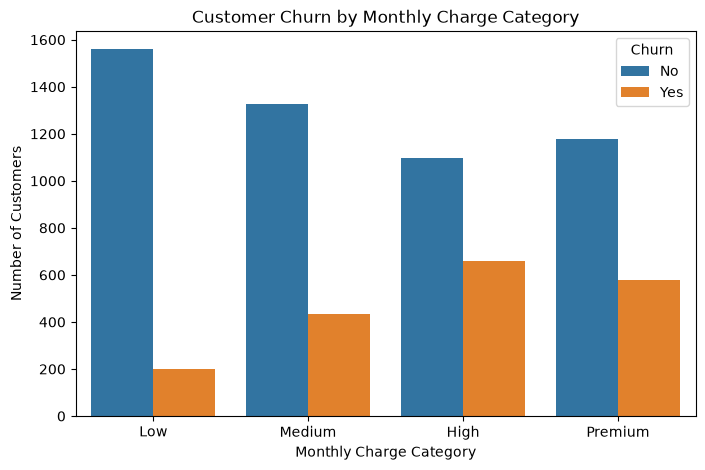

In [744]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="MonthlyChargeCategory",
    hue="Churn",
    order=["Low","Medium","High","Premium"]
)

plt.title("Customer Churn by Monthly Charge Category")
plt.xlabel("Monthly Charge Category")
plt.ylabel("Number of Customers")

plt.show()

### Business Interpretation

Grouping customers by monthly charge provides a clearer view of pricing segments and their relationship with churn.

This engineered feature helps identify whether customers paying higher monthly charges are more likely to leave, enabling pricing and retention strategies to be targeted toward the most vulnerable customer segments.

## Feature 3: Service Count

### Objective

Customers who subscribe to multiple value-added services may be more engaged with the company and therefore less likely to churn.

Instead of analyzing each service individually, we create a new feature called **Service Count**, which represents the total number of additional services subscribed to by each customer.

This feature helps identify whether customer engagement through multiple services improves retention.

In [745]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["ServiceCount"] = 0

for col in service_columns:
    df["ServiceCount"] += df[col].eq("Yes").astype(int)

In [746]:
df[service_columns + ["ServiceCount"]].head(10)

,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,ServiceCount
0,No,No phone service,No,Yes,No,No,No,No,1
1,Yes,No,Yes,No,Yes,No,No,No,3
2,Yes,No,Yes,Yes,No,No,No,No,3
3,No,No phone service,Yes,No,Yes,Yes,No,No,3
4,Yes,No,No,No,No,No,No,No,1
5,Yes,Yes,No,No,Yes,No,Yes,Yes,5
6,Yes,Yes,No,Yes,No,No,Yes,No,4
7,No,No phone service,Yes,No,No,No,No,No,1
8,Yes,Yes,No,No,Yes,Yes,Yes,Yes,6
9,Yes,No,Yes,Yes,No,No,No,No,3


In [747]:
df["ServiceCount"].value_counts().sort_index()

ServiceCount
0      80
1    1697
2    1186
3     965
4     921
5     906
6     674
7     395
8     208
Name: count, dtype: int64

In [748]:
pd.crosstab(
    df["ServiceCount"],
    df["Churn"]
)

Churn,No,Yes
ServiceCount,,
0,45,35
1,1338,359
2,796,390
3,613,352
4,632,289
5,674,232
6,522,152
7,346,49
8,197,11


In [749]:
pd.crosstab(
    df["ServiceCount"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
ServiceCount,,
0,56.250000,43.750000
1,78.845021,21.154979
2,67.116358,32.883642
3,63.523316,36.476684
4,68.621064,31.378936
5,74.392936,25.607064
6,77.448071,22.551929
7,87.594937,12.405063
8,94.711538,5.288462


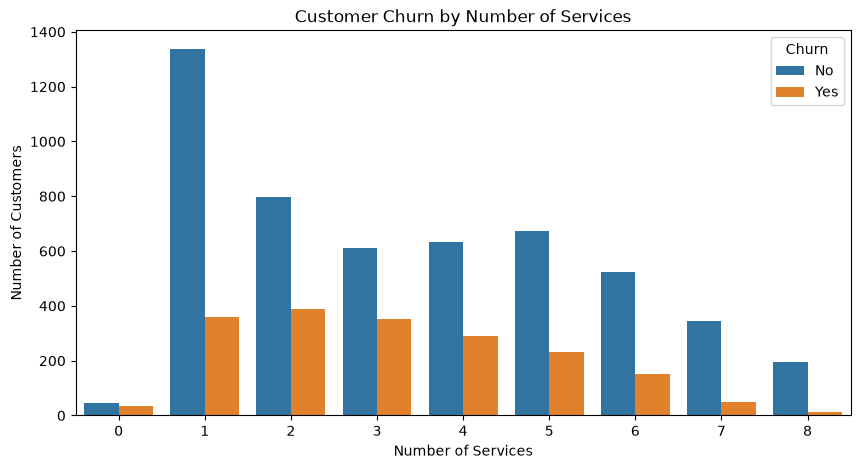

In [750]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="ServiceCount",
    hue="Churn"
)

plt.title("Customer Churn by Number of Services")
plt.xlabel("Number of Services")
plt.ylabel("Number of Customers")

plt.show()

### Business Interpretation

Service Count represents the number of value-added services subscribed to by each customer.

This engineered feature provides an overall measure of customer engagement. If churn decreases as Service Count increases, it suggests that customers who use more services become more loyal and are less likely to leave the company.

This insight can help the business design cross-selling strategies and bundled service offerings to improve customer retention.

## Feature 4: Customer Value Segment

### Objective

Not all customers contribute equally to the business.

Customer Value Segment classifies customers based on the total revenue they have generated for the company. This helps identify high-value customers who should receive priority in retention campaigns.

### Categories

- Low Value
- Medium Value
- High Value
- Premium Value

In [751]:
df["CustomerValue"] = pd.qcut(
    df["TotalCharges"],
    q=4,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "Premium Value"
    ]
)

In [752]:
df[["TotalCharges","CustomerValue"]].head(10)

,TotalCharges,CustomerValue
0,29.85,Low Value
1,1889.50,High Value
2,108.15,Low Value
3,1840.75,High Value
4,151.65,Low Value
5,820.50,Medium Value
6,1949.40,High Value
7,301.90,Low Value
8,3046.05,High Value
9,3487.95,High Value


In [753]:
df["CustomerValue"].value_counts()

CustomerValue
Low Value        1758
Medium Value     1758
High Value       1758
Premium Value    1758
Name: count, dtype: int64

In [754]:
pd.crosstab(
    df["CustomerValue"],
    df["Churn"]
)

Churn,No,Yes
CustomerValue,,
Low Value,994,764
Medium Value,1313,445
High Value,1353,405
Premium Value,1503,255


In [755]:
pd.crosstab(
    df["CustomerValue"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
CustomerValue,,
Low Value,56.541524,43.458476
Medium Value,74.687144,25.312856
High Value,76.962457,23.037543
Premium Value,85.494881,14.505119


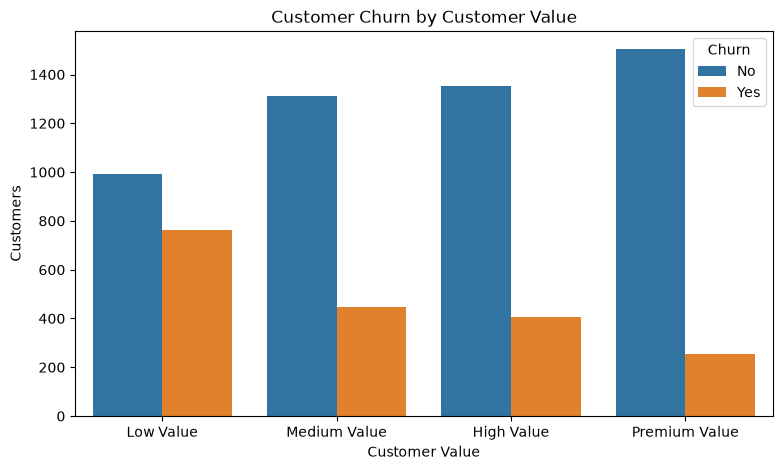

In [756]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="CustomerValue",
    hue="Churn",
    order=[
        "Low Value",
        "Medium Value",
        "High Value",
        "Premium Value"
    ]
)

plt.title("Customer Churn by Customer Value")

plt.xlabel("Customer Value")

plt.ylabel("Customers")

plt.show()

### Business Interpretation

Customer Value Segment groups customers according to the total revenue they have contributed to the company.

This feature helps identify whether low-value customers are more likely to churn than high-value customers.

From a business perspective, this segmentation enables targeted retention strategies by prioritizing customers with higher lifetime value.

## Feature 5: High Risk Customer

### Objective

Based on the exploratory analysis, customers with Month-to-Month contracts, Electronic Check payments, and no Online Security showed the highest churn rates.

This feature combines these high-risk characteristics into a single indicator, allowing the model to identify customers who require immediate retention efforts.

In [757]:
df["HighRiskCustomer"] = (
    (df["Contract"] == "Month-to-month") &
    (df["PaymentMethod"] == "Electronic check") &
    (df["OnlineSecurity"] == "No")
)

In [758]:
df["HighRiskCustomer"] = df["HighRiskCustomer"].map({
    True: "Yes",
    False: "No"
})

In [759]:
df["HighRiskCustomer"].value_counts()

HighRiskCustomer
No     5543
Yes    1489
Name: count, dtype: int64

In [760]:
pd.crosstab(df["HighRiskCustomer"], df["Churn"])

Churn,No,Yes
HighRiskCustomer,,
No,4547,996
Yes,616,873


In [761]:
pd.crosstab(
    df["HighRiskCustomer"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
HighRiskCustomer,,
No,82.031391,17.968609
Yes,41.370047,58.629953


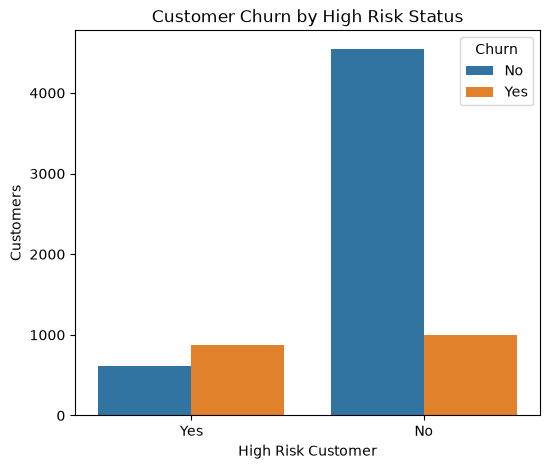

In [762]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="HighRiskCustomer",
    hue="Churn"
)

plt.title("Customer Churn by High Risk Status")
plt.xlabel("High Risk Customer")
plt.ylabel("Customers")

plt.show()

### Business Interpretation

The High Risk Customer feature combines multiple churn indicators identified during exploratory analysis.

Customers classified as high risk exhibit multiple characteristics associated with churn and should be prioritized for proactive retention campaigns, personalized offers, and customer support.

## Feature 6: Average Revenue Per Month

### Objective

Average Revenue Per Month measures how much revenue a customer generates each month on average.

Unlike Monthly Charges or Total Charges individually, this feature combines customer spending and tenure to provide a better understanding of customer value over time.

This feature may help identify high-paying customers who are at greater risk of churn.

In [763]:
df["AvgRevenuePerMonth"] = df["TotalCharges"] / df["tenure"].replace(0, 1)

In [764]:
df[["TotalCharges", "tenure", "AvgRevenuePerMonth"]].head(10)

,TotalCharges,tenure,AvgRevenuePerMonth
0,29.85,1,29.850000
1,1889.50,34,55.573529
2,108.15,2,54.075000
3,1840.75,45,40.905556
4,151.65,2,75.825000
5,820.50,8,102.562500
6,1949.40,22,88.609091
7,301.90,10,30.190000
8,3046.05,28,108.787500
9,3487.95,62,56.257258


In [765]:
df["AvgRevenuePerMonth"].describe()

count    7032.000000
mean       64.799424
std        30.185891
min        13.775000
25%        36.179891
50%        70.373239
75%        90.179560
max       121.400000
Name: AvgRevenuePerMonth, dtype: float64

In [766]:
df.groupby("Churn")["AvgRevenuePerMonth"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.312024,31.142619,13.775,25.355303,64.040385,87.762170,120.74918
Yes,1869.0,74.433154,24.961209,14.150,57.975000,79.312500,93.933784,121.40000


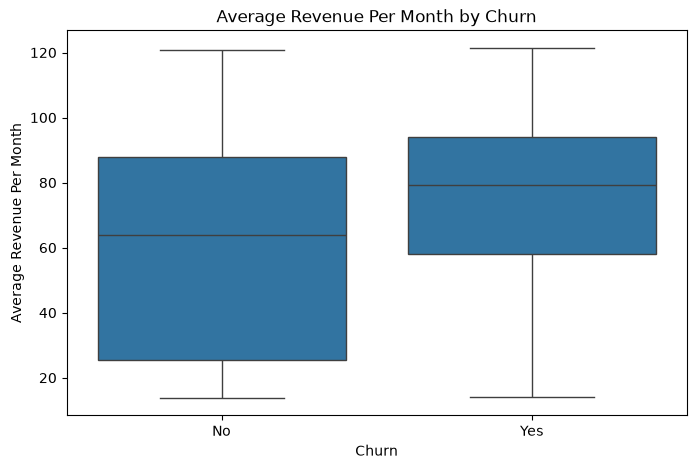

In [767]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="AvgRevenuePerMonth"
)

plt.title("Average Revenue Per Month by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Revenue Per Month")

plt.show()

### Business Interpretation

Average Revenue Per Month combines customer spending with customer tenure.

Customers generating higher monthly revenue are financially valuable to the company. Understanding whether these customers are more likely to churn helps prioritize retention efforts where they will have the greatest financial impact.

## Feature 7: Auto Payment

### Objective

Automatic payment methods indicate a higher level of customer commitment and reduce payment friction.

This engineered feature groups payment methods into automatic and non-automatic categories, making it easier to analyze the relationship between payment behavior and customer churn.

In [768]:
df["AutoPayment"] = df["PaymentMethod"].isin([
    "Bank transfer (automatic)",
    "Credit card (automatic)"
]).map({True: "Yes", False: "No"})

In [769]:
df[["PaymentMethod", "AutoPayment"]].head(10)

,PaymentMethod,AutoPayment
0,Electronic check,No
1,Mailed check,No
2,Mailed check,No
3,Bank transfer (automatic),Yes
4,Electronic check,No
5,Electronic check,No
6,Credit card (automatic),Yes
7,Mailed check,No
8,Electronic check,No
9,Bank transfer (automatic),Yes


In [770]:
pd.crosstab(df["AutoPayment"], df["Churn"])

Churn,No,Yes
AutoPayment,,
No,2590,1379
Yes,2573,490


In [771]:
pd.crosstab(
    df["AutoPayment"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
AutoPayment,,
No,65.255732,34.744268
Yes,84.002612,15.997388


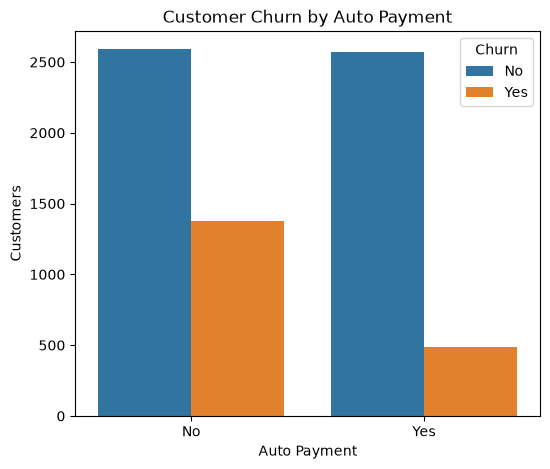

In [772]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="AutoPayment",
    hue="Churn"
)

plt.title("Customer Churn by Auto Payment")
plt.xlabel("Auto Payment")
plt.ylabel("Customers")

plt.show()

### Business Interpretation

Customers enrolled in automatic payment methods are generally more committed to the service and less likely to churn.

This feature simplifies payment behavior into a meaningful business category, allowing the company to identify customers who may benefit from incentives to adopt automatic payments.

# Data Preprocessing

## Objective

Machine learning algorithms cannot directly work with categorical (text) data. Before building a predictive model, the dataset must be prepared by removing unnecessary columns, encoding categorical variables into numerical values, and separating the input features from the target variable.

This preprocessing ensures that the data is suitable for machine learning while preserving meaningful business information.

In [773]:
df.shape

(7032, 28)

In [774]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   customerID             7032 non-null   str     
 1   gender                 7032 non-null   str     
 2   SeniorCitizen          7032 non-null   int64   
 3   Partner                7032 non-null   str     
 4   Dependents             7032 non-null   str     
 5   tenure                 7032 non-null   int64   
 6   PhoneService           7032 non-null   str     
 7   MultipleLines          7032 non-null   str     
 8   InternetService        7032 non-null   str     
 9   OnlineSecurity         7032 non-null   str     
 10  OnlineBackup           7032 non-null   str     
 11  DeviceProtection       7032 non-null   str     
 12  TechSupport            7032 non-null   str     
 13  StreamingTV            7032 non-null   str     
 14  StreamingMovies        7032 non-null   str     
 15  Con

In [775]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,MonthlyCharges,TotalCharges,Churn,TenureGroup,MonthlyChargeCategory,ServiceCount,CustomerValue,HighRiskCustomer,AvgRevenuePerMonth,AutoPayment
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,29.85,29.85,No,New,Low,1,Low Value,Yes,29.850000,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,56.95,1889.50,No,Established,Medium,3,High Value,No,55.573529,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,53.85,108.15,Yes,New,Medium,3,Low Value,No,54.075000,No
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,42.30,1840.75,No,Established,Medium,3,High Value,No,40.905556,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,70.70,151.65,Yes,New,High,1,Low Value,Yes,75.825000,No


In [776]:
df = df.drop(columns=["customerID"])

In [777]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup',
       'MonthlyChargeCategory', 'ServiceCount', 'CustomerValue',
       'HighRiskCustomer', 'AvgRevenuePerMonth', 'AutoPayment'],
      dtype='str')

In [778]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [779]:
print(X.shape)
print(y.shape)

(7032, 26)
(7032,)


In [780]:
X.dtypes

gender                        str
SeniorCitizen               int64
Partner                       str
Dependents                    str
tenure                      int64
PhoneService                  str
MultipleLines                 str
InternetService               str
OnlineSecurity                str
OnlineBackup                  str
DeviceProtection              str
TechSupport                   str
StreamingTV                   str
StreamingMovies               str
Contract                      str
PaperlessBilling              str
PaymentMethod                 str
MonthlyCharges            float64
TotalCharges              float64
TenureGroup              category
MonthlyChargeCategory    category
ServiceCount                int64
CustomerValue            category
HighRiskCustomer              str
AvgRevenuePerMonth        float64
AutoPayment                   str
dtype: object

In [781]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [782]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ServiceCount,AvgRevenuePerMonth,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,TenureGroup_Established,TenureGroup_Loyal,MonthlyChargeCategory_Medium,MonthlyChargeCategory_High,MonthlyChargeCategory_Premium,CustomerValue_Medium Value,CustomerValue_High Value,CustomerValue_Premium Value,HighRiskCustomer_Yes,AutoPayment_Yes
0,0,1,29.85,29.85,1,29.850000,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
1,0,34,56.95,1889.50,3,55.573529,True,False,False,True,...,True,False,True,False,False,False,True,False,False,False
2,0,2,53.85,108.15,3,54.075000,True,False,False,True,...,False,False,True,False,False,False,False,False,False,False
3,0,45,42.30,1840.75,3,40.905556,True,False,False,False,...,True,False,True,False,False,False,True,False,False,True
4,0,2,70.70,151.65,1,75.825000,False,False,False,True,...,False,False,False,True,False,False,False,False,True,False


In [783]:
y = y.map({
    "No": 0,
    "Yes": 1
})

In [784]:
y.value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

### Encoding Categorical Variables

Most machine learning algorithms require numerical input. Therefore, all categorical variables were converted into numerical format using **One-Hot Encoding**. The target variable (`Churn`) was also encoded into binary values (0 = No, 1 = Yes).

`drop_first=True` was used to avoid the dummy variable trap by removing one redundant category from each encoded feature.

In [785]:
y.value_counts()


Churn
0    5163
1    1869
Name: count, dtype: int64

## Train-Test Split

The dataset was divided into training and testing sets using an 80:20 ratio.

- **Training set (80%)**: Used to train the machine learning model.
- **Testing set (20%)**: Used to evaluate the model on unseen data.

The `stratify` parameter was used to preserve the original churn distribution in both datasets, while `random_state=42` ensures reproducible results.

In [786]:
import sklearn
print(sklearn.__version__)

1.9.0


In [787]:
from sklearn.model_selection import train_test_split

In [788]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [789]:
from sklearn.linear_model import LogisticRegression

In [790]:
log_model = LogisticRegression(max_iter=1000)

In [791]:
log_model.fit(X_train, y_train)

c:\Users\tusha\Downloads\churn analysis project\.venv-1\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [792]:
y_pred = log_model.predict(X_test)

# Logistic Regression Model

As a baseline model, Logistic Regression was trained to predict customer churn. It is a widely used algorithm for binary classification problems and provides an interpretable benchmark before evaluating more advanced models.

In [793]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [794]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7932


In [795]:
print(confusion_matrix(y_test, y_pred))

[[915 118]
 [173 201]]


In [796]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



ROC-AUC: 0.8342


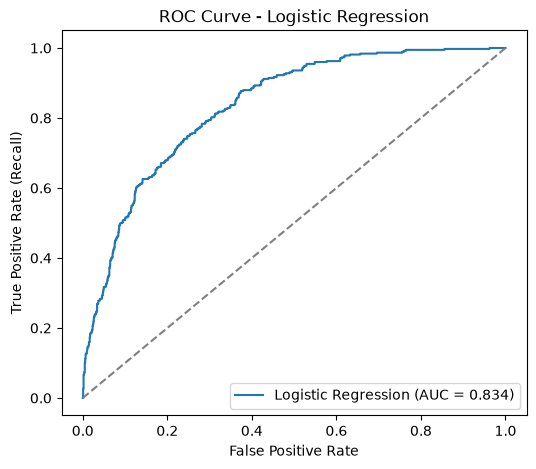

In [797]:
from sklearn.metrics import roc_auc_score, roc_curve

y_proba = log_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


### Observations

- Model Accuracy: **79.32%**
- The model performs well in predicting non-churn customers.
- Churn prediction recall is moderate (54%), indicating that some churning customers are missed.
- This model serves as a strong baseline for comparison with more advanced models.

# Random Forest

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

Unlike Logistic Regression, Random Forest can capture complex and non-linear relationships between customer attributes and churn behavior.

In [798]:
from sklearn.ensemble import RandomForestClassifier

In [799]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [800]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [801]:
y_pred_rf = rf_model.predict(X_test)

In [802]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.7839


In [803]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[916 117]
 [187 187]]


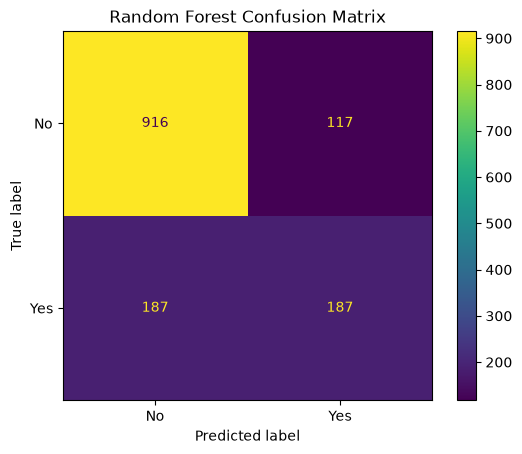

In [804]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No","Yes"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

In [805]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.50      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.78      1407



## Random Forest Results

The Random Forest model achieved an overall **accuracy of 78.39%**.

### Observations

- Accuracy: **78.39%**
- Precision (Churn): **0.62**
- Recall (Churn): **0.50**
- F1 Score (Churn): **0.55**

Although Random Forest is a more powerful ensemble algorithm, its performance on this dataset was slightly lower than Logistic Regression. This suggests that the churn patterns in this dataset are relatively linear and are effectively captured by Logistic Regression.

Therefore, **Logistic Regression was selected as the preferred model** for this project.

# Model Comparison

To determine the most suitable algorithm for customer churn prediction, the performance of Logistic Regression and Random Forest was compared using Accuracy, Precision, Recall, and F1 Score.
| Model               |   Accuracy | Precision |   Recall | F1 Score |
| ------------------- | ---------: | --------: | -------: | -------: |
| Logistic Regression | **79.32%** |  **0.63** | **0.54** | **0.58** |
| Random Forest       | **78.39%** |  **0.62** | **0.50** | **0.55** |


### Conclusion

Among the evaluated models, **Logistic Regression** achieved the best overall performance. It obtained slightly higher Accuracy, Precision, Recall, and F1 Score compared to Random Forest.

Based on these results, Logistic Regression was selected as the final model for customer churn prediction.

# Feature Importance

One advantage of Random Forest is its ability to estimate the relative importance of each feature used for prediction.

Feature importance helps identify which customer characteristics have the greatest influence on customer churn. These insights can guide business strategies aimed at improving customer retention.

In [806]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,TotalCharges,0.143151
5,AvgRevenuePerMonth,0.121600
1,tenure,0.116316
2,MonthlyCharges,0.112898
41,HighRiskCustomer_Yes,0.045131
12,InternetService_Fiber optic,0.032305
4,ServiceCount,0.031685
6,gender_Male,0.024067
30,PaymentMethod_Electronic check,0.022942
28,PaperlessBilling_Yes,0.021951


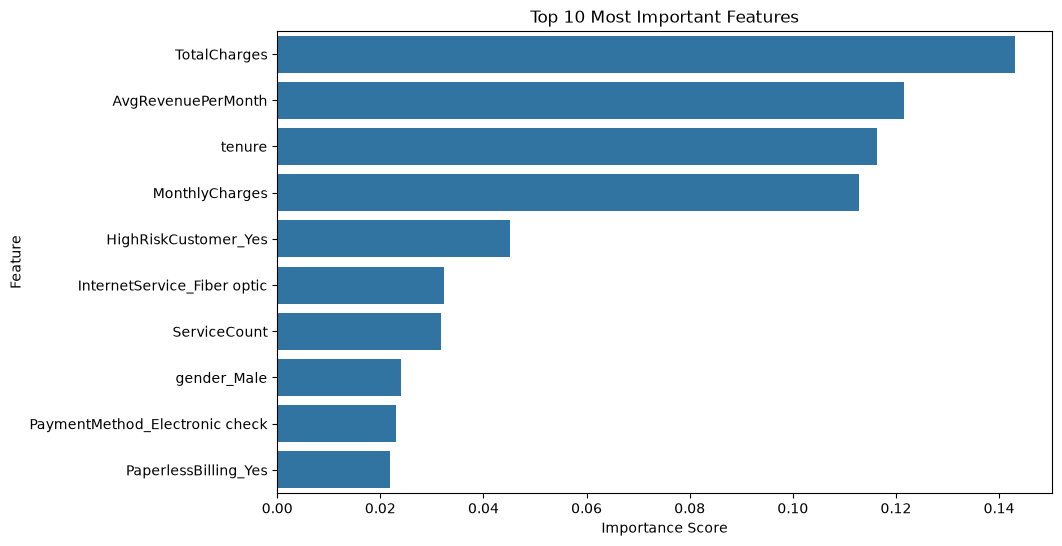

In [807]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

## Observations

The feature importance analysis highlights the variables that contribute most to customer churn prediction.

### Key Findings

- **TotalCharges** is the most influential feature, indicating that a customer's overall spending strongly affects churn behavior.
- **AvgRevenuePerMonth**, **tenure**, and **MonthlyCharges** are also among the most important predictors, suggesting that both customer value and subscription duration play significant roles.
- Customers identified as **High Risk** contribute noticeably to churn prediction.
- **Fiber Optic Internet Service** has a higher impact than other internet service types, supporting the findings from the exploratory data analysis.
- **Electronic Check** and **Paperless Billing** also influence churn, although their importance is lower than financial and tenure-related features.

Overall, financial variables and customer tenure were found to be the strongest drivers of customer churn.

# Business Recommendations

Based on the exploratory data analysis and machine learning results, the following recommendations can help reduce customer churn:

1. Encourage customers to move from month-to-month contracts to long-term contracts by offering discounts or loyalty benefits.

2. Identify new customers during their first year of service and implement targeted retention campaigns, as early-tenure customers exhibit the highest churn rate.

3. Monitor customers with high monthly charges and provide personalized plans or promotional offers to improve retention.

4. Improve the Fiber Optic customer experience by investigating service quality, pricing, and customer support, as Fiber Optic users have higher churn rates.

5. Promote Online Security and Tech Support services, since customers using these services are less likely to churn.

6. Encourage customers to adopt automatic payment methods instead of Electronic Check, which is associated with a higher churn rate.

7. Use the developed churn prediction model to identify high-risk customers and proactively offer incentives before they decide to leave.

# Final Conclusion

This project developed a machine learning solution to predict customer churn using the Telco Customer Churn dataset.

The project began with data cleaning and preprocessing, followed by extensive exploratory data analysis to identify the major factors influencing customer churn. Several new features, including **ServiceCount**, **TenureGroup**, **CustomerValue**, **AvgRevenuePerMonth**, and **HighRiskCustomer**, were engineered to improve the predictive capability of the models.

Two machine learning algorithms were evaluated:

- Logistic Regression
- Random Forest

Among the evaluated models, **Logistic Regression** achieved the best overall performance with an accuracy of **79.32%**, slightly outperforming Random Forest on this dataset.

Feature importance analysis further revealed that **TotalCharges**, **AvgRevenuePerMonth**, **tenure**, **MonthlyCharges**, and **Fiber Optic Internet Service** were among the strongest predictors of customer churn.

The findings suggest that customer churn is primarily influenced by contract type, customer tenure, monthly spending, total spending, internet service type, and payment method.

Overall, this project demonstrates how data analysis and machine learning can help businesses identify customers who are likely to churn and support proactive customer retention strategies.

# Future Scope

The current project can be further enhanced in several ways:

- Perform hyperparameter tuning to improve model performance.
- Evaluate additional algorithms such as XGBoost, LightGBM, or CatBoost.
- Address class imbalance using techniques such as SMOTE.
- Deploy the trained model as an interactive web application using Streamlit or Flask.
- Integrate the model into a real-time customer retention dashboard using Power BI or Tableau.

# Skills Demonstrated

During this project, the following skills were applied:

- Python Programming
- Pandas
- NumPy
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization (Matplotlib & Seaborn)
- Feature Engineering
- One-Hot Encoding
- Machine Learning
- Logistic Regression
- Random Forest
- Model Evaluation
- Business Insight Generation